In [1]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [2]:
api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=200)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper)

In [3]:
wiki.name

'wikipedia'

In [4]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader=WebBaseLoader("https://docs.smith.langchain.com/")
docs=loader.load()
documents=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200).split_documents(docs)
vectordb=FAISS.from_documents(documents,OpenAIEmbeddings())
retriever=vectordb.as_retriever()
retriever


/Users/sameerkhan/Desktop/sameerkhan/langchain/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x160aa5f30>, search_kwargs={})

In [5]:
from langchain_core.tools import create_retriever_tool
retriever_tool=create_retriever_tool(retriever,"langsmith_search",
                      "Search for information about LangSmith. For any questions about LangSmith, you must use this tool!")

In [6]:
retriever_tool.name

'langsmith_search'

In [7]:
## Arxiv Tool
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun

arxiv_wrapper=ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=200)
arxiv=ArxivQueryRun(api_wrapper=arxiv_wrapper)
arxiv.name

'arxiv'

In [8]:
tools=[wiki,arxiv,retriever_tool]

In [9]:
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/Users/sameerkhan/Desktop/sameerkhan/langchain/lib/python3.10/site-packages/wikipedia/__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=200)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=200)),
 Tool(name='langsmith_search', description='Search for information about LangSmith. For any questions about LangSmith, you must use this tool!', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x1093dc550>, retriever=VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langcha

In [10]:
from dotenv import load_dotenv

load_dotenv()
import os
os.environ['OPENAI_API_KEY']=os.getenv("OPENAI_API_KEY")
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)

In [11]:
from langsmith import Client
# Get the prompt to use - you can modify this!
prompt = Client().pull_prompt("hwchase17/openai-functions-agent")
prompt.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

In [12]:
### Agents
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage

# Extract a system prompt string if available
system_prompt = None
try:
    system_prompt = "\n\n".join([
        m.content for m in prompt.messages if getattr(m, "type", "") == "system"
    ])
except Exception:
    pass

agent = create_agent(model=llm, tools=tools, system_prompt=system_prompt)

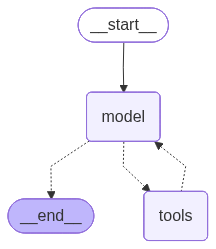

In [13]:
## Agent Executor
agent_executor = agent
agent_executor

In [14]:
agent_executor.invoke({"messages": [("user", "Tell me about Langsmith")]})

{'messages': [HumanMessage(content='Tell me about Langsmith', additional_kwargs={}, response_metadata={}, id='58564b4c-d82c-4255-b491-1d43998d8c47'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 209, 'total_tokens': 225, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CczNpWjkVTwwBPuk4r6VN08JmF7OB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--f521a7c1-6ba9-4bd2-80de-16ae88d830d5-0', tool_calls=[{'name': 'langsmith_search', 'args': {'query': 'Langsmith'}, 'id': 'call_sRmf1o71hYSjLYxOLndV3NgF', 'type': 'tool_call'}], usage_metadata={'input_tokens': 209, 'output_tokens': 16, 'total_tokens': 2

In [15]:
agent_executor.invoke({"messages": [("user", "What's the paper 1605.08386 about?")]})

{'messages': [HumanMessage(content="What's the paper 1605.08386 about?", additional_kwargs={}, response_metadata={}, id='4af340aa-3a33-44ea-a579-ea52993694f0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 216, 'total_tokens': 234, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CczNs5pWKUPdB9kHIbHkRO2EfqONn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--5b43054c-e425-4144-9e0a-69d305bdaf86-0', tool_calls=[{'name': 'arxiv', 'args': {'query': '1605.08386'}, 'id': 'call_iXUFKpntml0ffofHNm8FuZwT', 'type': 'tool_call'}], usage_metadata={'input_tokens': 216, 'output_tokens': 18, 'total_tokens': 